# ANN for regression
### Dataset name is "California Housing Prices"
### (https://www.kaggle.com/datasets/camnugent/california-housing-prices)
### The dataset is 20.6K rows. It contains 7 numeric columns, 2 columns with coordinates, and one column with text values. The target variable is "median house value". 
#### Background: I worked with this dataset in "Introduction to ML course", where I created fore different Jupyter notebooks. I implemented Linear and Polynomial Regression models: two of them used the ocean_proximity column, and the other two used the coordinates. The result showed that Polynomial Regression models achieved better metrics overall. There was no significant difference between using ocean_proximity or the coordinates, even when I attempted to calculate the distance from the coastline more precisely. Was recomended to calculate distance to nearest big cities.
#### In this project I will keep both ocean_proximity column and coordinates because they capture different aspects of location, coordinates - very precise location and Ocean proximity - higher level geographic grouping. As it was recomended to calculate distance to nearest big cities and will train ANN with and without this additional column, and will compare metrics.

In [2]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics


import tensorflow as tf
import keras
from keras import layers

## Loading the dataset

In [3]:
# load data 
df = pd.read_csv("housing.csv")

In [ ]:
# According to CharGPT is it enouth for small ANN model, good enough to learn basic patterns. 
len(df)

20640

In [ ]:
# the dataset has 10 clolumns, and one "ocean_proximity" is categorical. I will need to encode it properly (one-hot encoding)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<Axes: >

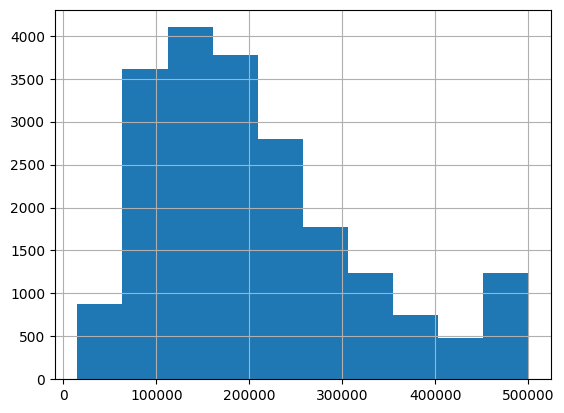

In [ ]:
# this plot shows that the target variable is right-skewed, there's a smaller group of homes with very high price, this tail indicates high-value homes
# for now I will keep the outliers, but might consider removing or transforming them later
df['median_house_value'].hist()

In [ ]:
# check if we have any missing values
df.isna().sum()

# we have missing values. I cannot fill them with median value as depends on how big a house is. I will drop them for now, not later will check how it will affect the results.

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [8]:
# dropping rows with missing values
df = df.dropna()

In [ ]:
df.isna().sum()

# now we don't have any missing values

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [ ]:
# check duplicates
int(df.duplicated().sum())

# no duplicates

0

## Handling the categorical variables